<a href="https://colab.research.google.com/github/izzat-ai/learning-ai/blob/main/projects/diabet_project/diabetes_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/refs/heads/main/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Datasetimizdagi ustunlar :

- Pregnancies - homilador bo'lish soni
- Glucose - glyukozaga(shakar miqdori) test natijasi
- BloodPressure - diastolik qon bosimi (mm Hg)
- SkinThickness Triceps - teri burmasining qalinligi (mm)
- Insulin - 2 soatlik sarum insulini (mu U/ml)
- BMI - Tana massasi indeksi (vazn kg / (m bo'yi) ^ 2)
- DiabetesPedigreeFunction - diabetning naslchilik funktsiyasi
- Age - Yosh (yil)
- Outcome - Class (0 - diabet yo'q, 1 - diabet)



In [4]:
df.shape

(768, 9)

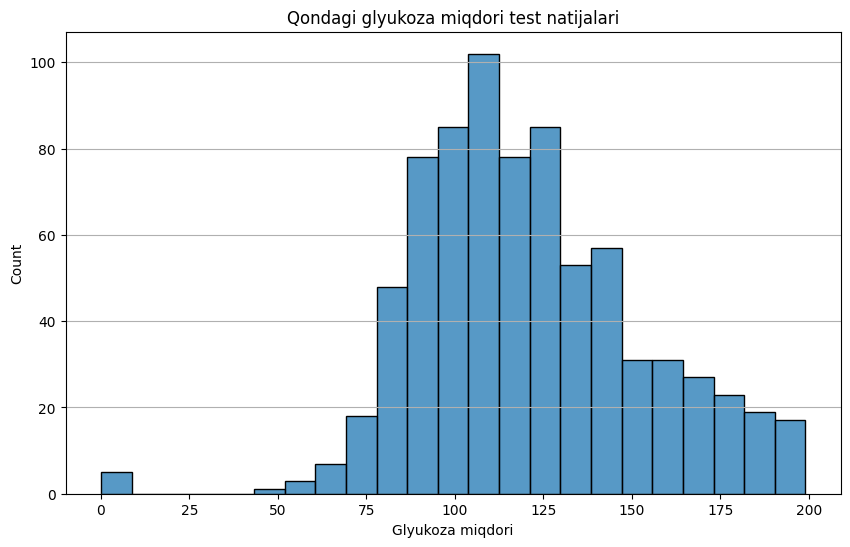

In [5]:
# qondagi glyukoza(shakar miqdorini) taqsimotini ko'ramiz , o'rtacha 70-100 mg atrofida bo'ladi
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Glucose')
plt.title("Qondagi glyukoza miqdori test natijalari")
plt.xlabel("Glyukoza miqdori")

plt.grid(axis='y')
plt.show()

- grafikning chap burchagi 0 ga yaqin bo'lgan joyda kichik ustun bor . Aslida tirik inson qonidagi glyukoza miqdori 0 bo'lishi mumkin emas . Bu ma'lumotlar bazasiga test natijasi kiritilmagan bo'sh qiymatlarni 0 bilan to'ldirib qo'yish natijasida yuzaga kelgan bo'lishi mumkin
- asosiy ma'lumotlar tahminan 80 dan 140 mg/dL gacha bo'lgan oraliqda . Normal glyukoza natijasi esa 70-100 mg dL bo'lishi kerak
- eng baland ustun 100 dan ortiq glyukoza miqdorida kuzatilgan
- 140 mg dl dan ham yuqori natijalar qayd etilgan , ular 150-200 mg dl , ular qandli diabet xavfi yoki mavjudligi yuqori bo'lgan guruhdir
- glyukoza miqdori 0 bo'lgan ma'lumotlarni keyinchalik to'ldiramiz yoki o'chirib yuboramiz

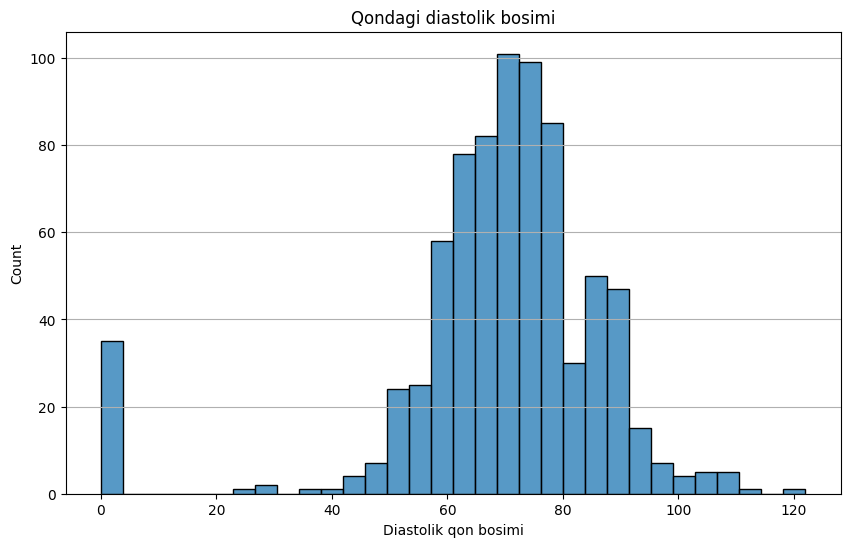

In [6]:
# yurak dam olgan paytdagi bosim taqsimotini ko'ramiz - diastolik qon bosimi
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='BloodPressure')
plt.title("Qondagi diastolik bosimi")
plt.xlabel("Diastolik qon bosimi")
plt.grid(axis='y')
plt.show()

- diastolik qon bosimi ma'lumotlarining katta qismi 60-80 mm hg ga tori keladi , bu normal taqsimot . 100 dan ortiq bemor aynan 70 mm hg atrofida
- grafik chap tomonida , 35 tadan ko'proq bemorlarni diastolik bosimi 0 bo'lganini ko'rishimiz mumkin . Aslida tirik insonda bunday bo'lishi mumkin emas
- 0 atrofidagi ma'lumotlarga keyinchalik ishlov berishimiz kerak

In [7]:
# SkinThickness - tana qalinligi ustuni 0 bo'lgan qiymatlar borligini tekshirish
(df['SkinThickness'] == 0).sum()

np.int64(227)

- bilak orqasidagi teri burmasining  qilinligi ustuni , bu tana yog' miqdorini o'lchash usuli - ko'proq yog' = ko'proq teri qalinligi

In [8]:
# Insulin ustunida 0 qiymatlar borligini aniqlash
(df['Insulin'] == 0).sum()

np.int64(374)

In [9]:
# tana massasi indeksi ustunidagi 0 qiymatlarni tekshirish
(df['BMI'] == 0).sum()

np.int64(11)

- yuqori BMI (ortiqcha vazn) - diabet xavfini oshiradi
- Yakuniy **xulosa** - tibbiyotda tirik insonning glyukozasi , qon bosimi , BMI si vahokazo 0 bo'lishi imkonsiz . Ma'lumotlarimizdagi 0 lar esa aslida NaN qiymatlar , u 0 lar NaN o'rnida ishlatilgan

In [10]:
# Glucose, BloodPressure, SkinThickness, Insulin va BMI ustunlaridagi 0 larni nan qilish
df['Glucose'] = df['Glucose'].replace(0, np.nan)
df['BloodPressure'] = df['BloodPressure'].replace(0, np.nan)
df['SkinThickness'] = df['SkinThickness'].replace(0, np.nan)
df['Insulin'] = df['Insulin'].replace(0, np.nan)
df['BMI'] = df['BMI'].replace(0, np.nan)

# nan qiymatlar sonini aniqlash
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [11]:
# target ustunimizni balansini teksirish
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


- 0 - sog'lom odamlar 500 ta , diabetga chalingan odamlar esa 268 ta
- ushbu datasetimiz biroz disbalans

In [12]:
# duplikatlarni aniqlash
df.duplicated().sum()

np.int64(0)

In [13]:
# ustun nomlarini tog'ri yozilganini tekshirish
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

### Train_test split

In [14]:
# features va target ustunlarni ajratish
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# train test splitlarga bo'lish | target ustunidagi balansni saqlagan holda bo'lish
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
X_train.shape

(614, 8)

In [16]:
y_train.shape

(614,)

In [22]:
X_train.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

### Exploraty Data Analysis

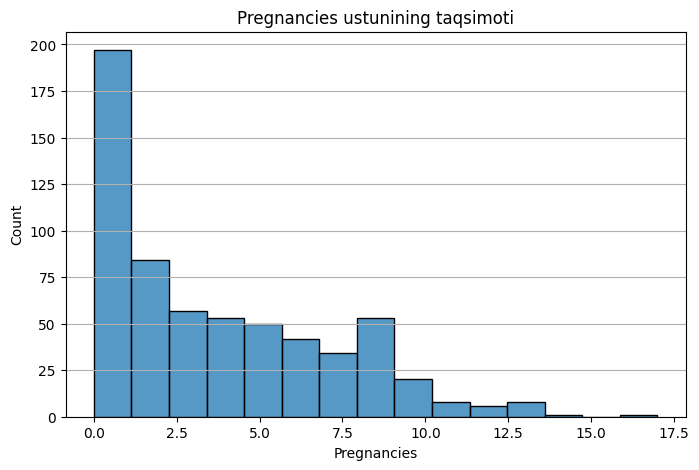

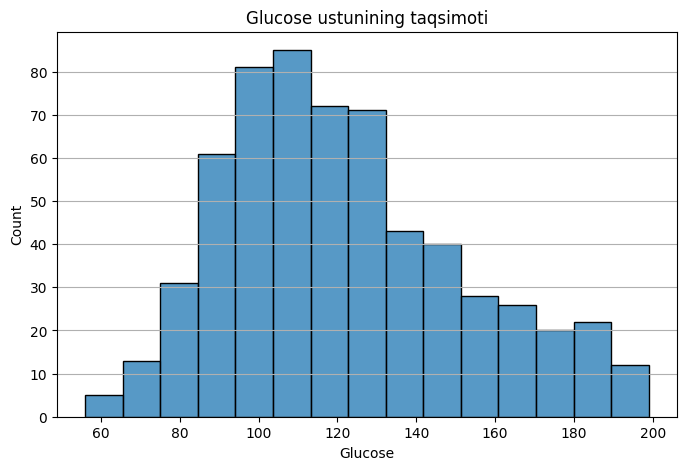

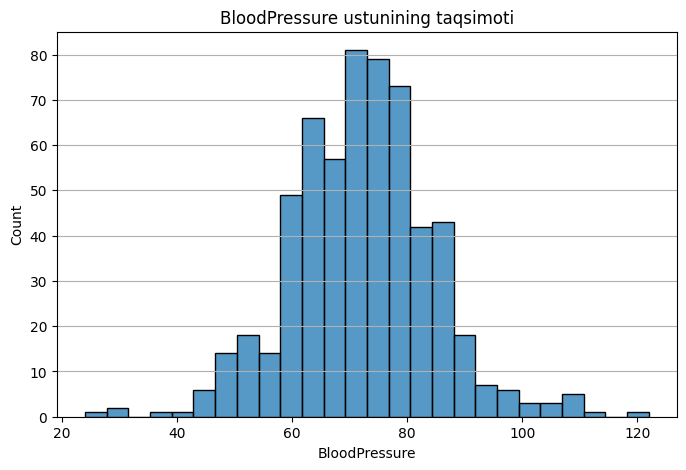

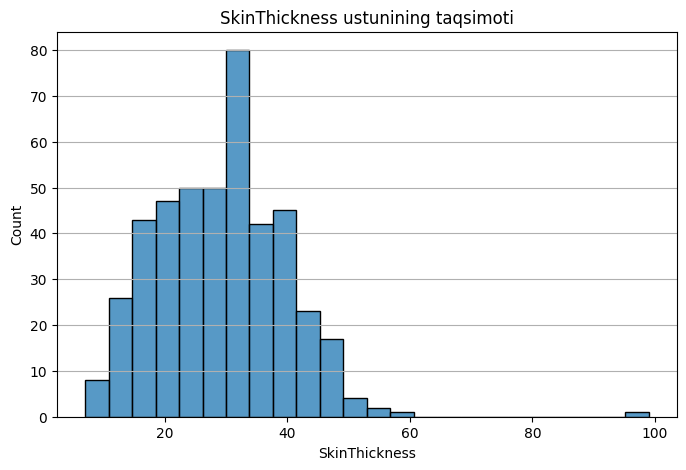

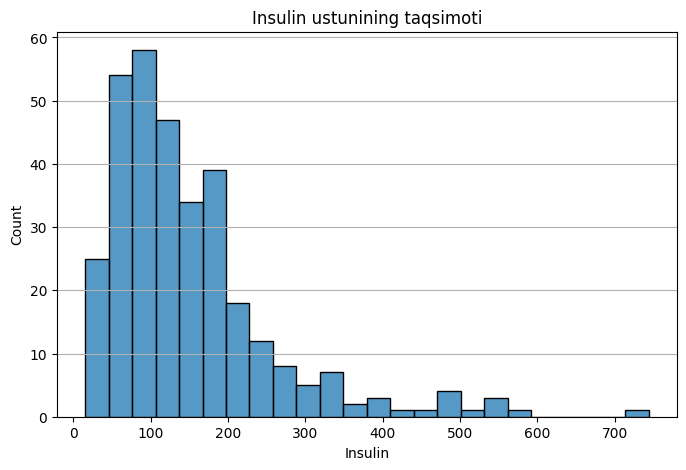

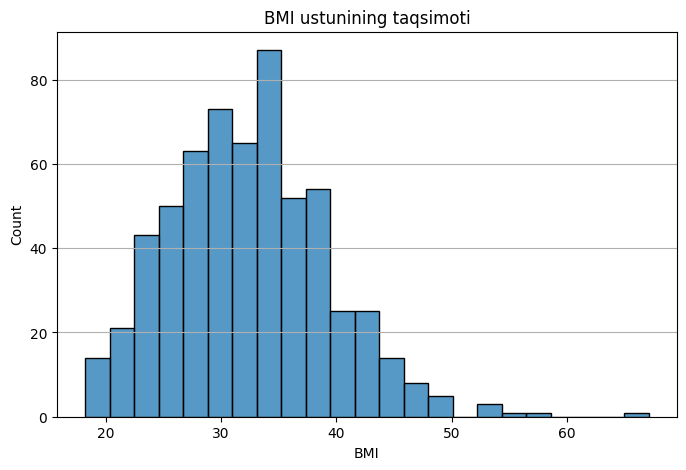

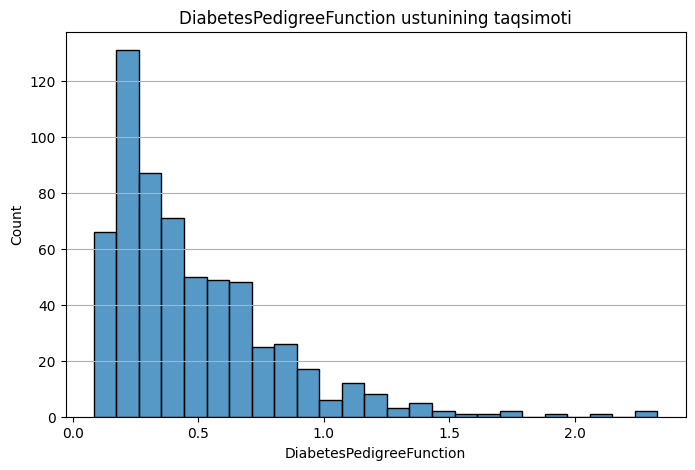

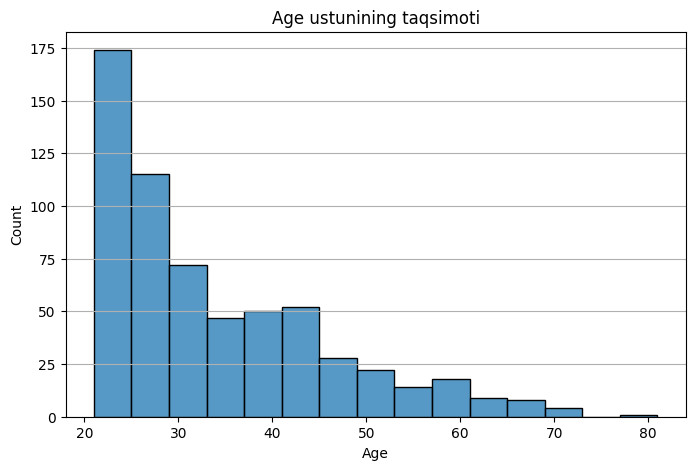

In [24]:
# har bir ustunni taqsimotini ko'rish
for col in X_train.columns:
  plt.figure(figsize=(8, 5))
  sns.histplot(data=X_train, x=X_train[col])
  plt.title(f"{col} ustunining taqsimoti")
  plt.xlabel(col)
  plt.grid(axis='y')
  plt.show()

- Glucose, BloodPressure va BMI ustunlari normal taqsimotga judayam yaqin
- Pregnancies, Insulin, DiabetesPedigreeFunction va Age ustunlarida ma'lumotlar chap tomonda to'plangan va o'ng tomonga qarab uzaygan
- Insulin (> 400), SkinThickness (> 90) va BMI (> 50) ustunlarida o'ng tomonda yakkalanib qolgan extremlar bor

- Be'morlarning ko'pchiligi 0, 1, 2 ta homiladorlik ko'rsatkichiga ega . Homiladorlik oshgani sari be'morlar soni kamaygan .

- Glucose , BloodPressure va BMI ustunlaridagi NaN larni guruhiga mos median qiymatlar bilan to'ldiramiz . Sababi ularni median qiymat bilan to'ldirsak ma'lumotlarimizda katta o'zgarishlar bo'miydi
- Lekin SkinThickness va Insulin kabi ustunlarni median bilan to'ldirsak , ma'lumotlarimiz taqsimoti keskin buziladi , kelajakda modelimiz ham u bilan soxat ma'lumotlar o'rganadi
- SkinThickness va Insulin ustunlarini KNN orqali - boshqa ustunlardagi o'xshash mijozlarga qarab insulin va terining qalinligini taxmin qilib to'ldirishdan foydalanamiz , bu eng to'g'ri yo'l bo'ladi

In [18]:
# diabet bor yoki yo'q insonlar bo'yicha guruhlab median qiymatlarni aniqlash
#df.groupby('Outcome')[['Glucose', 'BloodPressure', 'BMI']].median()

In [19]:
# glyukoza, bloodpressure va bmi ustunlarini o'zini mediana qiymati bilan nanlarni to'ldirish
#cols = ['Glucose', 'BloodPressure', 'BMI']
#for col in cols:
#  df[col] = df[col].fillna(df.groupby('Outcome')[col].transform('median'))

In [20]:
#df.isnull().sum()

- endi SkinThickness va Insulin ustunlaridagi NaN larni KNN yordamida to'ldiramiz
- KNN - bo'sh qiymatni to'ldirish uchun "menga o'xshash bo'lgan yana K ta bemorni ma'lumotlarini ber" degan tamoyil bilan ishledi . Ya'ni bemor45 yoshda , BMS si 33 , glyukozasi 140 , unga yoshi, vazni va qand miqdori deyarli bir xil bo'lgan boshqa 5 ta bemorni topaman va ularning insulini o'rtachasini olaman deydi

In [21]:
#from sklearn.impute import KNNImputer

# model yaratish
#imputer = KNNImputer(n_neighbors=5) # odatda 5 olinadi

# modelni o'qitish
#df_imputed = imputer.fit_transform(df)

# natijani df qilib o'qish
#df = pd.DataFrame(df_imputed, columns=df.columns)
#df.head()